In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikitplot as skplt

from sklearn import metrics as m

import suporte_modelos as sm
import funcoes_suporte as fs

In [2]:
fs.supressao_notacao(3)

## Load Data

In [3]:
PATH_MODELO = Path("../src/models")
PATH_DADOS = Path("../data/processed")

modelo = sm.load_pickle(PATH_MODELO / "model_xgb_tunned_hd.pkl")
x_validacao = sm.load_pickle(PATH_DADOS / "x_validacao.pkl")
y_validacao = sm.load_pickle(PATH_DADOS / "y_validacao.pkl")
cols_selected = sm.load_pickle(PATH_DADOS / "cols_selected.pkl")

In [4]:
df_tratado = sm.aplicar_modificacoes([x_validacao],[y_validacao],"resposta",cols_selected)

x_validacao = df_tratado[0].drop(columns=['resposta'])
y_validacao = df_tratado[0][['resposta']]

# 1. Probabilidade da classe prevista

Para o negócio, os erros tém significados diferentes:

| Tipo | Leitura técnica | Traduçãoo comercial |
| --- | --- | --- |
| Verdadeiro positivo | modelo prioriza e o cliente tinha interesse | ligação bem direcionada |
| Falso positivo | modelo prioriza, mas o cliente não tinha interesse | custo de ligação e tempo comercial desperdiçados |
| Falso negativo | modelo não prioriza, mas o cliente tinha interesse | oportunidade de venda perdida |
| Verdadeiro negativo | modelo não prioriza e o cliente não tinha interesse | ligação evitada corretamente |

Como o time de vendas tem uma quantidade limitada de ligações, o principal trade-off é: **reduzir desperdício sem perder clientes realmente interessados demais**.

In [5]:
y_proba = modelo.predict_proba(x_validacao)
y_true = y_validacao.to_numpy()
probabilidade_interesse = y_proba[:, 1]

taxa_base = y_true.mean()
total_clientes = len(y_true)
total_interessados = int(y_true.sum())

print(f"Total de clientes na validação: {total_clientes}")
print(f"Clientes realmente interessados: {total_interessados}")
print(f"Taxa base de interesse: {taxa_base:.2%}")

Total de clientes na validação: 57164
Clientes realmente interessados: 7141
Taxa base de interesse: 12.49%


# 2. Escolha Threshold

A tabela abaixo mostra o que acontece quando aumentamos o threshold. Thresholds baixos incluem mais clientes na lista de contato, mas trazem mais falsos positivos. Thresholds altos deixam a lista mais enxuta, mas aumentam falsos negativos.

As métricas mais úteis para a decisão são:

- **Precision:** entre os clientes priorizados, quantos realmente tinham interesse.
- **Recall:** entre todos os clientes interessados, quantos o modelo conseguiu capturar.
- **F1-score:** equilíbrio entre precision e recall.
- **Contatos por conversão:** esforço médio necessário para encontrar um cliente realmente interessado.

In [6]:
resultados = []

thresholds = np.arange(0.05, 1.00, 0.05)

vp_anterior = None
previstos_anteriores = None
perda_acumulada = 0

for th_value in thresholds:
    y_pred_th = np.where(probabilidade_interesse >= th_value, 1, 0)
    tn, fp, fn, tp = m.confusion_matrix(y_true, y_pred_th, labels=[0, 1]).ravel()

    total_previsto = int(y_pred_th.sum())
    perda_reais_vs_anterior = 0 if vp_anterior is None else int(vp_anterior - int(tp))
    perda_previstos_vs_anterior = 0 if previstos_anteriores is None else int(previstos_anteriores - total_previsto)
    perda_acumulada += perda_reais_vs_anterior

    resultados.append({
        "threshold": round(th_value, 2),
        "total_previsto": total_previsto,
        "qtde_contatos_para_1_conversao": (round((total_previsto / int(tp)),2) if int(tp) != 0 else 0  ),
        "verdadeiros_positivos": int(tp),
        "perda_real_acumulada": int(perda_acumulada),
        "perda_reais_vs_anterior": perda_reais_vs_anterior,
        "perda_previstos_vs_anterior": perda_previstos_vs_anterior,
        "perc_contatos_eliminados_que_eram_reais": ( round((perda_reais_vs_anterior / perda_previstos_vs_anterior),2) if perda_previstos_vs_anterior != 0 else 0  ),
        "precision": m.precision_score(y_true , y_pred_th, zero_division=0),
        "recall": m.recall_score(y_true , y_pred_th, zero_division=0),
        "f1_score": m.f1_score(y_true , y_pred_th, zero_division=0),
        "falsos_positivos": int(fp),
        "falsos_negativos": int(fn),
        "verdadeiro_negativo": int(tn)
    })

    vp_anterior = int(tp)
    previstos_anteriores = total_previsto

threshold_df = pd.DataFrame(resultados)
threshold_df

,threshold,total_previsto,qtde_contatos_para_1_conversao,verdadeiros_positivos,perda_real_acumulada,perda_reais_vs_anterior,perda_previstos_vs_anterior,perc_contatos_eliminados_que_eram_reais,precision,recall,f1_score,falsos_positivos,falsos_negativos,verdadeiro_negativo
0,0.050,48994,6.860,7138,0,0,0,0.000,0.146,1.000,0.254,41856,3,8167
1,0.100,31473,4.420,7118,20,20,17521,0.000,0.226,0.997,0.369,24355,23,25668
2,0.150,28949,4.100,7060,78,58,2524,0.020,0.244,0.989,0.391,21889,81,28134
3,0.200,26607,3.820,6968,170,92,2342,0.040,0.262,0.976,0.413,19639,173,30384
4,0.250,24858,3.640,6826,312,142,1749,0.080,0.275,0.956,0.427,18032,315,31991
5,0.300,22920,3.460,6620,518,206,1938,0.110,0.289,0.927,0.440,16300,521,33723
6,0.350,20729,3.300,6283,855,337,2191,0.150,0.303,0.880,0.451,14446,858,35577
7,0.400,18517,3.150,5885,1253,398,2212,0.180,0.318,0.824,0.459,12632,1256,37391
8,0.450,15878,2.980,5320,1818,565,2639,0.210,0.335,0.745,0.462,10558,1821,39465
9,0.500,11423,2.770,4128,3010,1192,4455,0.270,0.361,0.578,0.445,7295,3013,42728


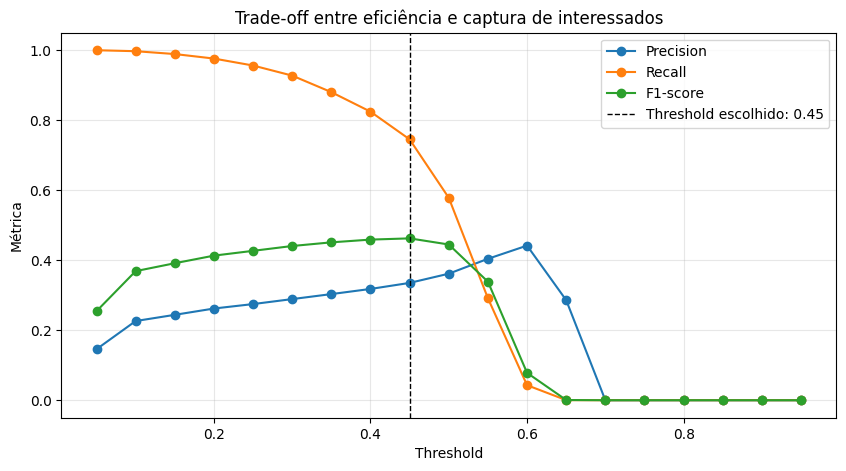

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
ax.plot(threshold_df["threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
ax.axvline(0.45, color="black", linestyle="--", linewidth=1, label="Threshold escolhido: 0.45")

ax.set_title("Trade-off entre eficiência e captura de interessados")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

In [8]:
THRESHOLD_ESCOLHIDO = 0.45

linha_threshold = threshold_df.loc[threshold_df["threshold"] == THRESHOLD_ESCOLHIDO].squeeze()

linha_threshold.to_frame("valor")

,valor
threshold,0.450
total_previsto,15878.000
qtde_contatos_para_1_conversao,2.980
verdadeiros_positivos,5320.000
perda_real_acumulada,1818.000
perda_reais_vs_anterior,565.000
perda_previstos_vs_anterior,2639.000
perc_contatos_eliminados_que_eram_reais,0.210
precision,0.335
recall,0.745


O threshold de 0.45 foi selecionado por representar o melhor equilíbrio operacional entre precision e recall.

Abaixo desse valor há excesso de falsos positivos; acima dele ocorre perda acentuada de clientes realmente interessados.

O threshold 0.45 preserva 74,5% dos positivos reais, apresenta o maior F1-score e evita a queda abrupta observada a partir de 0.50.

Com threshold de 0.45, é necessário contatar aproximadamente 3 clientes para obter 1 conversão real. Embora thresholds maiores reduzam esse número, eles também eliminam uma parcela excessiva de clientes realmente interessados.

Ao aumentar o threshold de 0.45 para 0.50, o modelo deixa de prever 4.455 clientes como potenciais interessados, dos quais 1.192 eram clientes realmente positivos. Ou seja, aproximadamente 26,8% dos contatos eliminados correspondiam a clientes que efetivamente teriam interesse.

Dessa forma, o threshold 0.45 foi escolhido como configuração operacional do modelo, por oferecer o melhor equilíbrio entre eficiência comercial e capacidade de captura de clientes.

### Qual a porcentagem de clientes interessados em adquirir um seguro de automóvel, o time de vendas conseguirá contatar fazendo 20.000 ligações?

In [9]:
N_CONTATOS = 20_000

base_scored = x_validacao.copy()
base_scored["resposta"] = y_true
base_scored["probabilidade_interesse"] = probabilidade_interesse
base_scored["previsao_threshold"] = (probabilidade_interesse >= THRESHOLD_ESCOLHIDO).astype(int)

base_priorizada = base_scored.sort_values("probabilidade_interesse",ascending=False,).reset_index(drop=True)

top_20k = base_priorizada.head(N_CONTATOS).copy()

interessados_top_20k = int(top_20k["resposta"].sum())
percentual_interessados_capturados = interessados_top_20k / total_interessados
percentual_base_contatada = N_CONTATOS / total_clientes

print(f"Clientes contatados: {N_CONTATOS:,} ({percentual_base_contatada:.2%} da base)")
print(f"Interessados capturados no Top 20k: {interessados_top_20k:,}")
print(f"Percentual dos interessados reais capturados: {percentual_interessados_capturados:.2%}")

Clientes contatados: 20,000 (34.99% da base)
Interessados capturados no Top 20k: 6,168
Percentual dos interessados reais capturados: 86.37%


In [10]:
lift_table = sm.tabela_lift(
    base_scored["resposta"],
    base_scored["probabilidade_interesse"],
    bins=20,
)

lift_table.head(8)

,faixa,clientes,interessados,precision_faixa,lift,clientes_acumulados,interessados_acumulados,recall_acumulado
0,0,2859,1197,0.419,3.352,2859,1197,0.168
1,1,2858,1083,0.379,3.033,5717,2280,0.319
2,2,2858,964,0.337,2.700,8575,3244,0.454
3,3,2858,886,0.310,2.482,11433,4130,0.578
4,4,2858,793,0.277,2.221,14291,4923,0.689
5,5,2858,669,0.234,1.874,17149,5592,0.783
6,6,2859,576,0.201,1.613,20008,6168,0.864
7,7,2858,447,0.156,1.252,22866,6615,0.926


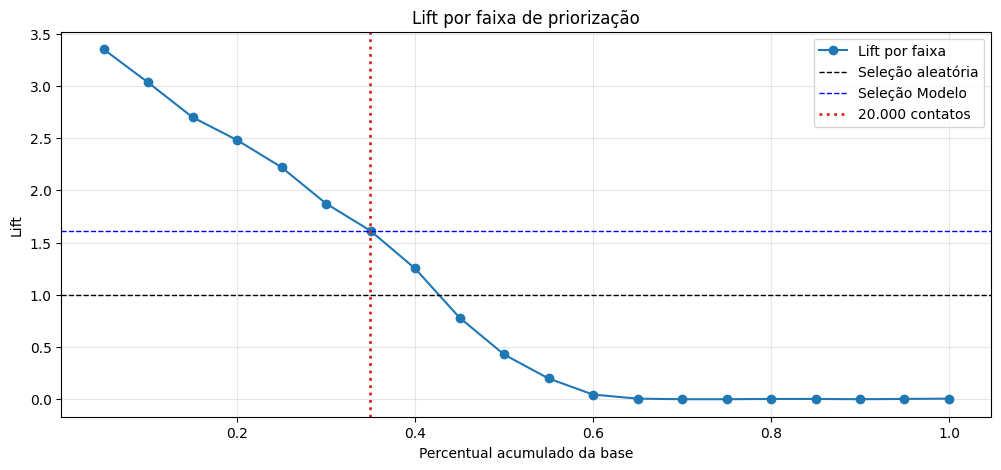

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    lift_table["clientes_acumulados"] / total_clientes,
    lift_table["lift"],
    marker="o",
    label="Lift por faixa",
)
ax.axhline(1, color="black", linestyle="--", linewidth=1, label="Seleção aleatória")
ax.axhline(lift_table["lift"][6], color="blue", linestyle="--", linewidth=1, label="Seleção Modelo")
ax.axvline(N_CONTATOS / total_clientes, color="tab:red", linestyle=":", linewidth=2, label="20.000 contatos")

ax.set_title("Lift por faixa de priorização")
ax.set_xlabel("Percentual acumulado da base")
ax.set_ylabel("Lift")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

Até 35% da base de dados, aproximadamente 20k linhas, o modelo ainda é melhor em 1.6 vezes comparando com escolha randomica para 20000 mil clientes.

# Tradução para Negócio

## Assumindo Premissas

In [12]:
CUSTO_LIGACAO = 2.50
CAPACIDADE_DIA = 2_000
TICKET_MEDIO = 2_000

interessados_aleatorio_esperado = N_CONTATOS * taxa_base
custo_campanha = N_CONTATOS * CUSTO_LIGACAO
dias_campanha = N_CONTATOS / CAPACIDADE_DIA

receita_aleatoria = interessados_aleatorio_esperado * TICKET_MEDIO
receita_modelo = interessados_top_20k * TICKET_MEDIO
incremento_receita = receita_modelo - receita_aleatoria
multiplicador_receita = receita_modelo / receita_aleatoria

comparacao_campanha = pd.DataFrame({
    "cenario": ["Aleatório", "Modelo"],
    "contatos": [N_CONTATOS, N_CONTATOS],
    "dias_operacao": [dias_campanha, dias_campanha],
    "custo_ligacoes": [custo_campanha, custo_campanha],
    "interessados_estimados": [interessados_aleatorio_esperado, interessados_top_20k],
    "receita_estimada": [receita_aleatoria, receita_modelo],
    "receita_liquida_ligacoes": [receita_aleatoria - custo_campanha, receita_modelo - custo_campanha],
})

comparacao_campanha

,cenario,contatos,dias_operacao,custo_ligacoes,interessados_estimados,receita_estimada,receita_liquida_ligacoes
0,Aleatório,20000,10.000,50000.000,2498.426,4996851.165,4946851.165
1,Modelo,20000,10.000,50000.000,6168.000,12336000.000,12286000.000


In [13]:
print(f"Receita estimada sem prioriza??o: R$ {receita_aleatoria:,.2f}")
print(f"Receita estimada com modelo: R$ {receita_modelo:,.2f}")
print(f"Incremento estimado de receita: R$ {incremento_receita:,.2f}")
print(f"Multiplicador de receita: {multiplicador_receita:.2f}x")
print(f"Custo da campanha: R$ {custo_campanha:,.2f}")
print(f"Tempo de opera??o: {dias_campanha:.1f} dias")

Receita estimada sem prioriza??o: R$ 4,996,851.17
Receita estimada com modelo: R$ 12,336,000.00
Incremento estimado de receita: R$ 7,339,148.83
Multiplicador de receita: 2.47x
Custo da campanha: R$ 50,000.00
Tempo de opera??o: 10.0 dias


## Resumo operacional Top 20k

Esta tabela resume o impacto operacional da campanha de 20.000 contatos. A comparação mantém o mesmo volume de ligacões nos dois cenários e muda apenas a priorizacão: com modelo, os clientes são ordenados pelo score; sem modelo, usamos a taxa média de interesse da base.


In [14]:
interessados_sem_modelo = interessados_aleatorio_esperado
taxa_interesse_modelo = interessados_top_20k / N_CONTATOS
taxa_interesse_sem_modelo = interessados_sem_modelo / N_CONTATOS

custo_por_interessado_modelo = custo_campanha / interessados_top_20k
custo_por_interessado_sem_modelo = custo_campanha / interessados_sem_modelo

contatos_por_interessado_modelo = N_CONTATOS / interessados_top_20k
contatos_por_interessado_sem_modelo = N_CONTATOS / interessados_sem_modelo

receita_por_contato_modelo = receita_modelo / N_CONTATOS
receita_por_contato_sem_modelo = receita_aleatoria / N_CONTATOS

receita_liquida_modelo = receita_modelo - custo_campanha
receita_liquida_sem_modelo = receita_aleatoria - custo_campanha

linhas_resumo = [
    ("Custo", "Contatos realizados", f"{N_CONTATOS:,.0f}", f"{N_CONTATOS:,.0f}"),
    ("Custo", "Dias de operação", f"{dias_campanha:,.2f}", f"{dias_campanha:,.2f}"),
    ("Custo", "Custo total das ligações", f"R$ {custo_campanha:,.2f}", f"R$ {custo_campanha:,.2f}"),
    ("Custo", "Contatos por interessado", f"{contatos_por_interessado_modelo:,.2f}", f"{contatos_por_interessado_sem_modelo:,.2f}"),
    ("Custo", "Custo por interessado", f"R$ {custo_por_interessado_modelo:,.2f}", f"R$ {custo_por_interessado_sem_modelo:,.2f}"),
    ("Receita", "Interessados alcançados", f"{interessados_top_20k:,.0f}", f"{interessados_sem_modelo:,.2f}"),
    ("Receita", "Taxa de interesse no Top 20k", f"{taxa_interesse_modelo:.2%}", f"{taxa_interesse_sem_modelo:.2%}"),
    ("Receita", "Receita estimada", f"R$ {receita_modelo:,.2f}", f"R$ {receita_aleatoria:,.2f}"),
    ("Receita", "Receita líquida após ligações", f"R$ {receita_liquida_modelo:,.2f}", f"R$ {receita_liquida_sem_modelo:,.2f}"),
    ("Receita", "Receita por contato", f"R$ {receita_por_contato_modelo:,.2f}", f"R$ {receita_por_contato_sem_modelo:,.2f}"),
    ("Receita", "Receita incremental", f"R$ {incremento_receita:,.2f}", "R$ 0.00"),
    ("Receita", "Multiplicador de receita", f"{multiplicador_receita:.2f}x", "1.00x"),
]

resumo_operacional_top20k = (
    pd.DataFrame(linhas_resumo, columns=["Grupo", "Métrica", "Com modelo", "Sem modelo"])
    .set_index(["Grupo", "Métrica"])
)

resumo_operacional_top20k


Com modelo       Sem modelo
Grupo   Métrica                                                         
Custo   Contatos realizados                      20,000           20,000
        Dias de operação                          10.00            10.00
        Custo total das ligações           R$ 50,000.00     R$ 50,000.00
        Contatos por interessado                   3.24             8.01
        Custo por interessado                   R$ 8.11         R$ 20.01
Receita Interessados alcançados                   6,168         2,498.43
        Taxa de interesse no Top 20k             30.84%           12.49%
        Receita estimada               R$ 12,336,000.00  R$ 4,996,851.17
        Receita líquida após ligações  R$ 12,286,000.00  R$ 4,946,851.17
        Receita por contato                   R$ 616.80        R$ 249.84
        Receita incremental             R$ 7,339,148.83          R$ 0.00
        Multiplicador de receita                  2.47x            1.00x

## Receita diária acumulada

Os gráficos abaixo comparam a receita estimada para uma campanha de 20.000 contatos, considerando a capacidade de 2.000 ligações por dia.

A linha do modelo usa a ordem priorizada pelo score. A linha sem modelo usa a taxa média de interesse da base, simulando uma abordagem sem priorização.

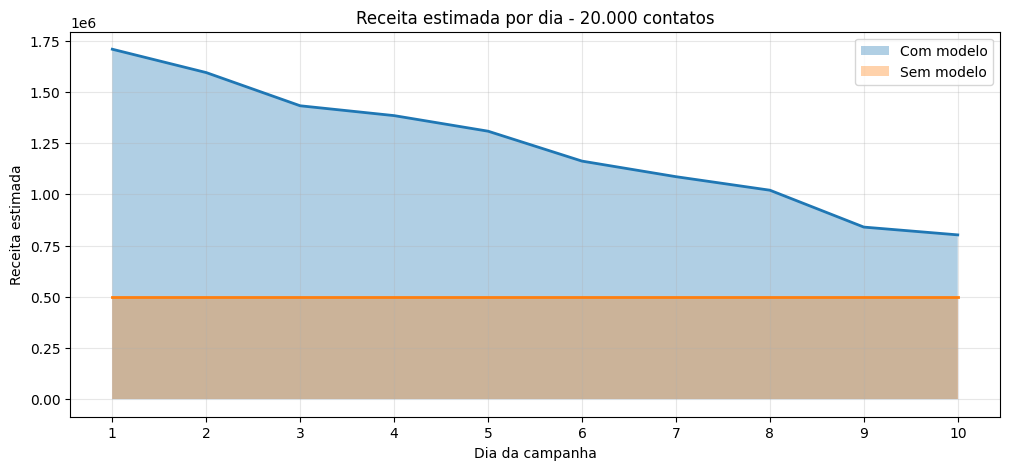

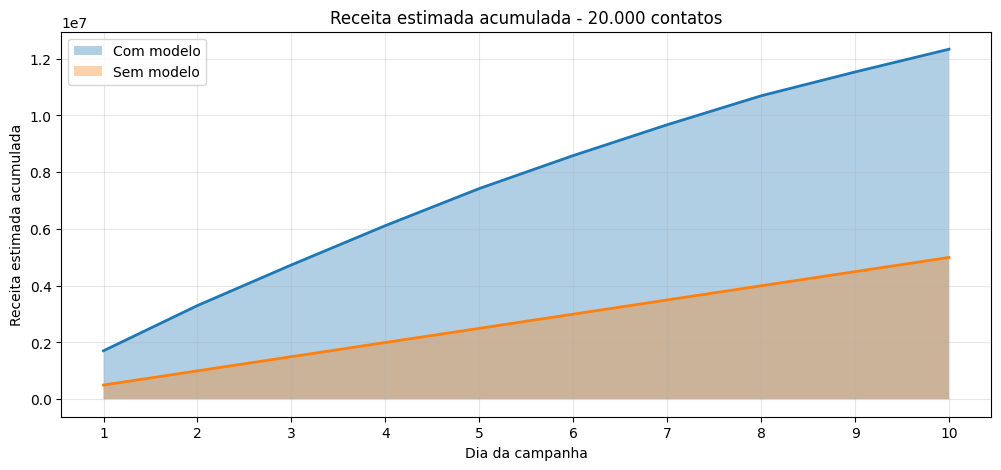

In [15]:
dias_campanha_int = int(np.ceil(N_CONTATOS / CAPACIDADE_DIA))
dias = np.arange(1, dias_campanha_int + 1)

top_20k_dias = top_20k.copy()
top_20k_dias["dia_campanha"] = np.ceil((np.arange(len(top_20k_dias)) + 1) / CAPACIDADE_DIA).astype(int)

receita_modelo_dia = (
    top_20k_dias.groupby("dia_campanha")["resposta"]
    .sum()
    .reindex(dias, fill_value=0)
    * TICKET_MEDIO
)

contatos_por_dia = pd.Series(
    np.minimum(CAPACIDADE_DIA, N_CONTATOS - (dias - 1) * CAPACIDADE_DIA),
    index=dias,
)
receita_sem_modelo_dia = contatos_por_dia * taxa_base * TICKET_MEDIO

receita_por_dia = pd.DataFrame({
    "dia": dias,
    "receita_modelo": receita_modelo_dia.to_numpy(),
    "receita_sem_modelo": receita_sem_modelo_dia.to_numpy(),
})

receita_por_dia["receita_modelo_acumulada"] = receita_por_dia["receita_modelo"].cumsum()
receita_por_dia["receita_sem_modelo_acumulada"] = receita_por_dia["receita_sem_modelo"].cumsum()


fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(receita_por_dia["dia"], receita_por_dia["receita_modelo"], alpha=0.35, label="Com modelo")
ax.fill_between(receita_por_dia["dia"], receita_por_dia["receita_sem_modelo"], alpha=0.35, label="Sem modelo")
ax.plot(receita_por_dia["dia"], receita_por_dia["receita_modelo"], linewidth=2)
ax.plot(receita_por_dia["dia"], receita_por_dia["receita_sem_modelo"], linewidth=2)

ax.set_title("Receita estimada por dia - 20.000 contatos")
ax.set_xlabel("Dia da campanha")
ax.set_ylabel("Receita estimada")

ax.set_xticks(dias)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(receita_por_dia["dia"], receita_por_dia["receita_modelo_acumulada"], alpha=0.35, label="Com modelo")
ax.fill_between(receita_por_dia["dia"], receita_por_dia["receita_sem_modelo_acumulada"], alpha=0.35, label="Sem modelo")
ax.plot(receita_por_dia["dia"], receita_por_dia["receita_modelo_acumulada"], linewidth=2)
ax.plot(receita_por_dia["dia"], receita_por_dia["receita_sem_modelo_acumulada"], linewidth=2)

ax.set_title("Receita estimada acumulada - 20.000 contatos")
ax.set_xlabel("Dia da campanha")
ax.set_ylabel("Receita estimada acumulada")

ax.set_xticks(dias)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## Custo da ligações

Quanto custaria obter o mesmo resultado sem modelo?

Quantas ligações aleatórias seriam necessárias para encontrar a mesma quantidade de interessados capturada pelo Top 20k priorizado?

In [16]:
contatos_aleatorios_necessarios = interessados_top_20k / taxa_base
custo_aleatorio_equivalente = contatos_aleatorios_necessarios * CUSTO_LIGACAO
dias_aleatorio_equivalente = contatos_aleatorios_necessarios / CAPACIDADE_DIA

ligacoes_economizadas = contatos_aleatorios_necessarios - N_CONTATOS
custo_economizado = custo_aleatorio_equivalente - custo_campanha
dias_economizados = dias_aleatorio_equivalente - dias_campanha

print(f"Interessados obtidos com o modelo: {interessados_top_20k:,.0f}")
print(f"Contatos aleatorios necessarios para o mesmo resultado: {contatos_aleatorios_necessarios:,.0f}")
print(f"Custo aleatorio equivalente: {custo_aleatorio_equivalente:,.2f}")
print(f"Dias aleatorios equivalentes: {dias_aleatorio_equivalente:,.2f}")
print(f"Ligacoes economizadas com o modelo: {ligacoes_economizadas:,.0f}")
print(f"Custo economizado com o modelo: {custo_economizado:,.2f}")
print(f"Dias economizados com o modelo: {dias_economizados:,.2f}")

Interessados obtidos com o modelo: 6,168
Contatos aleatorios necessarios para o mesmo resultado: 49,375
Custo aleatorio equivalente: 123,437.74
Dias aleatorios equivalentes: 24.69
Ligacoes economizadas com o modelo: 29,375
Custo economizado com o modelo: 73,437.74
Dias economizados com o modelo: 14.69


## Cen?rios complementares: 40.000 liga??es e captura de 80% dos interessados

Nesta etapa s?o respondidas as duas perguntas de neg?cio que ficaram em aberto:

1. Se a capacidade do time de vendas aumentar para 40.000 liga??es, qual porcentagem de clientes interessados ser? contatada?
2. Quantas liga??es o time de vendas precisa fazer para contatar 80% dos clientes interessados?


In [17]:
def avaliar_top_k(base_priorizada, k, total_interessados, total_clientes, taxa_base):
    """Calcula a performance operacional para os k clientes mais prov?veis."""
    k = min(k, total_clientes)
    top_k = base_priorizada.head(k).copy()
    interessados_capturados = int(top_k["resposta"].sum())

    return {
        "contatos": k,
        "perc_base_contatada": k / total_clientes,
        "interessados_capturados": interessados_capturados,
        "perc_interessados_capturados": interessados_capturados / total_interessados,
        "taxa_interesse_top_k": interessados_capturados / k,
        "lift_vs_aleatorio": (interessados_capturados / k) / taxa_base,
        "interessados_esperados_aleatorio": k * taxa_base,
        "ganho_interessados_vs_aleatorio": interessados_capturados - (k * taxa_base),
    }


In [18]:
N_CONTATOS_40K = 40_000

resultado_40k = avaliar_top_k(
    base_priorizada=base_priorizada,
    k=N_CONTATOS_40K,
    total_interessados=total_interessados,
    total_clientes=total_clientes,
    taxa_base=taxa_base,
)

resultado_40k_df = pd.DataFrame([resultado_40k])
resultado_40k_df


,contatos,perc_base_contatada,interessados_capturados,perc_interessados_capturados,taxa_interesse_top_k,lift_vs_aleatorio,interessados_esperados_aleatorio,ganho_interessados_vs_aleatorio
0,40000,0.700,7136,0.999,0.178,1.428,4996.851,2139.149


In [19]:
print(f"Clientes contatados: {resultado_40k['contatos']:,}")
print(f"Percentual da base contatada: {resultado_40k['perc_base_contatada']:.2%}")
print(f"Interessados capturados no Top 40k: {resultado_40k['interessados_capturados']:,}")
print(f"Percentual dos interessados reais capturados: {resultado_40k['perc_interessados_capturados']:.2%}")
print(f"Taxa de interesse no Top 40k: {resultado_40k['taxa_interesse_top_k']:.2%}")
print(f"Lift vs sele??o aleat?ria: {resultado_40k['lift_vs_aleatorio']:.2f}x")
print(f"Interessados esperados sem modelo: {resultado_40k['interessados_esperados_aleatorio']:,.0f}")
print(f"Ganho de interessados vs aleat?rio: {resultado_40k['ganho_interessados_vs_aleatorio']:,.0f}")


Clientes contatados: 40,000
Percentual da base contatada: 69.97%
Interessados capturados no Top 40k: 7,136
Percentual dos interessados reais capturados: 99.93%
Taxa de interesse no Top 40k: 17.84%
Lift vs sele??o aleat?ria: 1.43x
Interessados esperados sem modelo: 4,997
Ganho de interessados vs aleat?rio: 2,139


### Resposta para 40.000 liga??es

Com 40.000 liga??es, o modelo captura praticamente todos os clientes interessados da base de valida??o. A efici?ncia marginal diminui em rela??o ao Top 20k, pois os clientes mais prov?veis j? foram priorizados nas primeiras posi??es do ranking, mas o recall acumulado fica muito pr?ximo de 100%.


In [20]:
META_RECALL = 0.80

base_meta = base_priorizada.copy()
base_meta["interessados_acumulados"] = base_meta["resposta"].cumsum()
base_meta["recall_acumulado"] = base_meta["interessados_acumulados"] / total_interessados
base_meta["ranking"] = np.arange(1, len(base_meta) + 1)

posicao_meta_80 = int(base_meta.loc[base_meta["recall_acumulado"] >= META_RECALL, "ranking"].iloc[0])
interessados_meta_80 = int(base_meta.loc[posicao_meta_80 - 1, "interessados_acumulados"])

resultado_80 = avaliar_top_k(
    base_priorizada=base_priorizada,
    k=posicao_meta_80,
    total_interessados=total_interessados,
    total_clientes=total_clientes,
    taxa_base=taxa_base,
)

resultado_80_df = pd.DataFrame([resultado_80])
resultado_80_df


,contatos,perc_base_contatada,interessados_capturados,perc_interessados_capturados,taxa_interesse_top_k,lift_vs_aleatorio,interessados_esperados_aleatorio,ganho_interessados_vs_aleatorio
0,17727,0.310,5713,0.800,0.322,2.580,2214.480,3498.520


In [21]:
print(f"Meta de captura dos interessados: {META_RECALL:.0%}")
print(f"Liga??es necess?rias para atingir a meta: {resultado_80['contatos']:,}")
print(f"Percentual da base contatada: {resultado_80['perc_base_contatada']:.2%}")
print(f"Interessados capturados: {resultado_80['interessados_capturados']:,}")
print(f"Percentual dos interessados reais capturados: {resultado_80['perc_interessados_capturados']:.2%}")
print(f"Taxa de interesse at? esse ponto: {resultado_80['taxa_interesse_top_k']:.2%}")
print(f"Lift vs sele??o aleat?ria: {resultado_80['lift_vs_aleatorio']:.2f}x")


Meta de captura dos interessados: 80%
Liga??es necess?rias para atingir a meta: 17,727
Percentual da base contatada: 31.01%
Interessados capturados: 5,713
Percentual dos interessados reais capturados: 80.00%
Taxa de interesse at? esse ponto: 32.23%
Lift vs sele??o aleat?ria: 2.58x


### Resposta para captura de 80% dos interessados

Para capturar 80% dos clientes interessados, o time de vendas precisa realizar aproximadamente 17.727 liga??es, seguindo a ordena??o do score gerado pelo modelo. Esse volume representa cerca de 31% da base de valida??o e mant?m uma taxa de interesse superior ? taxa m?dia da base.


In [22]:
cenarios_operacionais = pd.DataFrame([
    avaliar_top_k(base_priorizada, 20_000, total_interessados, total_clientes, taxa_base),
    avaliar_top_k(base_priorizada, 40_000, total_interessados, total_clientes, taxa_base),
    avaliar_top_k(base_priorizada, posicao_meta_80, total_interessados, total_clientes, taxa_base),
])

cenarios_operacionais.insert(0, "cenario", ["Top 20k", "Top 40k", "Meta 80% interessados"])

cenarios_operacionais_formatado = cenarios_operacionais.copy()
cenarios_operacionais_formatado["perc_base_contatada"] = cenarios_operacionais_formatado["perc_base_contatada"].map(lambda x: f"{x:.2%}")
cenarios_operacionais_formatado["perc_interessados_capturados"] = cenarios_operacionais_formatado["perc_interessados_capturados"].map(lambda x: f"{x:.2%}")
cenarios_operacionais_formatado["taxa_interesse_top_k"] = cenarios_operacionais_formatado["taxa_interesse_top_k"].map(lambda x: f"{x:.2%}")
cenarios_operacionais_formatado["lift_vs_aleatorio"] = cenarios_operacionais_formatado["lift_vs_aleatorio"].map(lambda x: f"{x:.2f}x")
cenarios_operacionais_formatado["interessados_esperados_aleatorio"] = cenarios_operacionais_formatado["interessados_esperados_aleatorio"].map(lambda x: f"{x:,.0f}")
cenarios_operacionais_formatado["ganho_interessados_vs_aleatorio"] = cenarios_operacionais_formatado["ganho_interessados_vs_aleatorio"].map(lambda x: f"{x:,.0f}")

cenarios_operacionais_formatado


,cenario,contatos,perc_base_contatada,interessados_capturados,perc_interessados_capturados,taxa_interesse_top_k,lift_vs_aleatorio,interessados_esperados_aleatorio,ganho_interessados_vs_aleatorio
0,Top 20k,20000,34.99%,6168,86.37%,30.84%,2.47x,"2,498","3,670"
1,Top 40k,40000,69.97%,7136,99.93%,17.84%,1.43x,"4,997","2,139"
2,Meta 80% interessados,17727,31.01%,5713,80.00%,32.23%,2.58x,"2,214","3,499"
